In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import numpy as np
import copy as cp
import os
import pandas as pd
import json
import pickle
import openai
import json_repair

#from blablador import Models, Completions, ChatCompletions, TokenCount
import ast
import re
from itertools import chain
#import country_converter as coco
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy
import time
from openai import OpenAI
from pathlib import Path

from src.data import *
from src.impact_def import *
from src.prompts_impacts import *
from src.LLM_functions import *
from src.post_process_impact import *
from src.classOutput import ImpactList

In [13]:
#load input data
file_path = DATA_IN_JSONS + "filtered_report_types_nat_hazards_summary-header.json"#"nathaz_ifrc_reports_info_processed.json"

# Open and read the JSON file
with open(file_path, "r") as json_file:
    ifrc_reports_processed = json.load(json_file)
ifrc_reports_df = pd.DataFrame(ifrc_reports_processed)

#select appealCode to process
fnla = "labelled_example_haz-subtype-emdat_laura.csv"
labelled_laura = pd.read_csv(DATA_LABELLED+fnla)
fnlu = "labelled_reports_luca.csv"
labelled_luca = pd.read_csv(DATA_LABELLED+fnlu).drop(["Unnamed: 0"],axis=1)

#reformat to be consistent
ifrc_reports_df.rename({"date":"reportDate"}, inplace=True, axis=1)
ifrc_reports_df["reportDate"] = pd.to_datetime(ifrc_reports_df["reportDate"], dayfirst=True)
labelled_laura["reportDate"] = pd.to_datetime(labelled_laura["reportDate"], dayfirst=True) #reformat date to be consistent
labelled_luca["reportDate"] = pd.to_datetime(labelled_luca["reportDate"]) #reformat date to be consistent
labelled_reports = pd.concat([labelled_laura, labelled_luca]).reset_index(drop=True)

In [49]:
model = "meta-llama/llama-4-scout-17b-16e-instruct"
MODEL_NAME = model
nreports = 50
res_savename = f"llm_response_impact_{nreports}rep_test_{MODEL_NAME.replace('/', '_')}.csv"#replace characters causing issues when saving
response_df = pd.read_csv(DATA_OUT_LLMS+res_savename)
# test_reports_in = ifrc_reports_df.iloc[:nreports]

# response, response_df = get_event_impacts_v2(test_reports_in, res_savename)

In [37]:
response_df.head()

,impactType,impactValue,impactUnit,location,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,impactsAnnotation,appealCode,country,reportDate,disasterType,nathaz_text,impactAnnotation,impactsAnnotation_corrected,impactsAnnotation_similarity_score
0,Affected People,25335.0,people,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","[As of16 September,25,335 people5,067 families...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,[Appeal MDRBO017 Country Bolivia Hazard Fire T...,NaN,"Page 2 18 As of 16 September, 25,335 people 5,...",0.722857
1,Human Deaths,2.0,people,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","[At least60 homes were affected, and two death...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,[Appeal MDRBO017 Country Bolivia Hazard Fire T...,NaN,"At least 60 homes were affected, and two death...",0.878234
2,Residential Buildings,60.0,homes,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","[At least60 homes were affected, and two death...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,[Appeal MDRBO017 Country Bolivia Hazard Fire T...,NaN,"At least 60 homes were affected, and two death...",0.878234
3,Agriculture,7000.0,crops,['Santa Cruz'],2024.0,9.0,11.0,NaN,NaN,NaN,"['wildfire', 'forest fire']",[According to information collected by the Dep...,MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,[Appeal MDRBO017 Country Bolivia Hazard Fire T...,NaN,According to the situation report of the Human...,0.849152
4,Residential Buildings,22.0,houses,['Santa Cruz'],2024.0,9.0,11.0,NaN,NaN,NaN,"['wildfire', 'forest fire']",[According to information collected by the Dep...,MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,[Appeal MDRBO017 Country Bolivia Hazard Fire T...,NaN,According to the situation report of the Human...,0.849152


# Check sentences

In [23]:
response_df = df_parse_to_list(response_df, ["nathaz_text", "impactsAnnotation"])
response_test = compute_similarity_per_row(response_df)

/home/lhasbini/como_school/como_project4/src/post_process_impact.py:47: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  


nan


(array([  1.,   0.,   0.,   0.,   4.,  14.,  30.,  79.,  87., 158.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

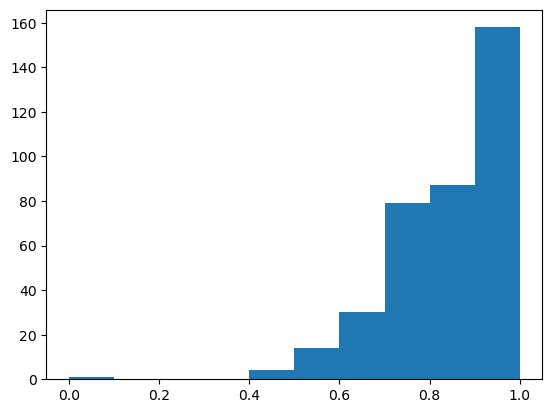

In [34]:
import matplotlib.pyplot as plt
plt.hist(response_test.impactsAnnotation_similarity_score)

# Check units 

In [58]:
response_test = correct_units_human(response_df)

In [59]:
response_df.head(8)

,impactType,impactValue,impactUnit,location,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,impactsAnnotation,appealCode,country,reportDate,disasterType,nathaz_text,impactAnnotation
0,Affected People,25335.0,people,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","['As of16 September,25,335 people5,067 familie...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
1,Human Deaths,2.0,people,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","['At least60 homes were affected, and two deat...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
2,Residential Buildings,60.0,homes,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","['At least60 homes were affected, and two deat...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
3,Agriculture,7000.0,crops,['Santa Cruz'],2024.0,9.0,11.0,NaN,NaN,NaN,"['wildfire', 'forest fire']",['According to information collected by the De...,MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
4,Residential Buildings,22.0,houses,['Santa Cruz'],2024.0,9.0,11.0,NaN,NaN,NaN,"['wildfire', 'forest fire']",['According to information collected by the De...,MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
5,Affected People,11100.0,people,"['Algeria', 'Bchar', 'Tamanrasset', 'El Bayadh']",2024.0,9.0,5.0,NaN,NaN,NaN,"['riverine flood', 'flash flood']","['On September8,2024, a severe tropical distur...",MDRDZ011,Algeria,2024-09-22 00:00:00,Famine / Food Insecurity,['DREF Operation Algeria Flood 2024 Bechar App...,NaN
6,Displaced People,2220.0,families,"['Bchar', 'Tamanrasset', 'El Bayadh']",2024.0,9.0,5.0,NaN,NaN,NaN,"['riverine flood', 'flash flood']","['The flooding, which began around September5t...",MDRDZ011,Algeria,2024-09-22 00:00:00,Famine / Food Insecurity,['DREF Operation Algeria Flood 2024 Bechar App...,NaN
7,Human Deaths,5.0,people,"['Bechar', 'Naama']",2024.0,9.0,5.0,NaN,NaN,NaN,"['riverine flood', 'flash flood']","['Tragically, the floods have claimed five liv...",MDRDZ011,Algeria,2024-09-22 00:00:00,Famine / Food Insecurity,['DREF Operation Algeria Flood 2024 Bechar App...,NaN


In [60]:
response_test.head(8)

,impactType,impactValue,impactUnit,location,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,impactsAnnotation,appealCode,country,reportDate,disasterType,nathaz_text,impactAnnotation
0,Affected People,25335.0,people,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","['As of16 September,25,335 people5,067 familie...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
1,Human Deaths,2.0,people,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","['At least60 homes were affected, and two deat...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
2,Residential Buildings,60.0,homes,"['Bolivia', 'Santa Cruz', 'Beni']",2024.0,9.0,8.0,NaN,NaN,NaN,"['wildfire', 'forest fire']","['At least60 homes were affected, and two deat...",MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
3,Agriculture,7000.0,crops,['Santa Cruz'],2024.0,9.0,11.0,NaN,NaN,NaN,"['wildfire', 'forest fire']",['According to information collected by the De...,MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
4,Residential Buildings,22.0,houses,['Santa Cruz'],2024.0,9.0,11.0,NaN,NaN,NaN,"['wildfire', 'forest fire']",['According to information collected by the De...,MDRBO017,Bolivia,2024-09-23 00:00:00,Fire,['Appeal MDRBO017 Country Bolivia Hazard Fire ...,NaN
5,Affected People,11100.0,people,"['Algeria', 'Bchar', 'Tamanrasset', 'El Bayadh']",2024.0,9.0,5.0,NaN,NaN,NaN,"['riverine flood', 'flash flood']","['On September8,2024, a severe tropical distur...",MDRDZ011,Algeria,2024-09-22 00:00:00,Famine / Food Insecurity,['DREF Operation Algeria Flood 2024 Bechar App...,NaN
6,Displaced People,8880.0,people,"['Bchar', 'Tamanrasset', 'El Bayadh']",2024.0,9.0,5.0,NaN,NaN,NaN,"['riverine flood', 'flash flood']","['The flooding, which began around September5t...",MDRDZ011,Algeria,2024-09-22 00:00:00,Famine / Food Insecurity,['DREF Operation Algeria Flood 2024 Bechar App...,NaN
7,Human Deaths,5.0,people,"['Bechar', 'Naama']",2024.0,9.0,5.0,NaN,NaN,NaN,"['riverine flood', 'flash flood']","['Tragically, the floods have claimed five liv...",MDRDZ011,Algeria,2024-09-22 00:00:00,Famine / Food Insecurity,['DREF Operation Algeria Flood 2024 Bechar App...,NaN
